<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/19B_NeuroFHIR_TRACE_Longitudinal_TestRetest_CrossSite_Reliability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 19B
## Real Longitudinal / Test-Retest / Cross-Site Reliability Validation

**Project:** NeuroFHIR-TRACE — Provenance-Aware Reliability Gating for Longitudinal Neuroimaging AI

### Why this notebook exists

Notebook 19A demonstrated the TRACE engineering pipeline:

**evidence family → stability signals → reliability state → provenance → FHIR propagation**

However, the 19A synthetic instability reference reused several of the same variables used by the TRACE gate. That is useful for engineering validation, but it is not a sufficiently independent scientific evaluation.

Notebook 19B fixes that problem.

### Primary goals

1. Load a real or semi-real longitudinal evidence-family table.
2. Split subjects into **development** and **held-out** groups without visit leakage.
3. Quantify repeatability and technical variability independently of the final TRACE gate.
4. Compute:
   - ICC
   - Bland–Altman agreement
   - coefficient of variation
   - longitudinal change-direction concordance
   - site/scanner effects
   - technical-vs-biological change ratios
   - optional mixed-effects variance decomposition
5. Construct an **independent instability reference** from replicate/test-retest disagreement or known perturbation provenance.
6. Save a frozen development artifact for Notebook 20, where TRACE thresholds will be calibrated and evaluated on held-out subjects.


This notebook should answer:

> When anatomy is expected to be approximately stable, how much apparent biomarker change is introduced by technical variation, and can that variation be separated from longitudinal biological change?


In [1]:

# ============================================================
# 0. COLAB SETUP
# ============================================================

!pip -q install pandas numpy scipy scikit-learn statsmodels pyarrow matplotlib

from pathlib import Path
import json, os, math, random, warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/neurofhir_trace")
INPUT_DIR = ROOT / "inputs"
OUT_DIR = ROOT / "outputs_19B"
FIG_DIR = OUT_DIR / "figures"

for p in [INPUT_DIR, OUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Workspace:", ROOT)


Workspace: /content/neurofhir_trace



# 1. Input contract

Notebook 19B expects an evidence-family table with one row per:

**subject × visit × technical condition / replicate**

Minimum columns:

```text
subject_id
visit_id
biomarker_value
perturbation
site
scanner
model_version
preprocessing_version
provenance_completeness
```

Preferred additional columns:

```text
time_from_baseline_days
replicate_id
is_test_retest
is_real_scan
is_controlled_perturbation
source_image
```

If `19A` output exists, this notebook will load it. Otherwise it generates a runnable demonstration dataset.

For the final paper, replace the demonstration data with real longitudinal ADNI-derived evidence and, if possible, an independent public test-retest or cross-site cohort.


In [2]:

# ============================================================
# 1. LOAD 19A OUTPUT IF AVAILABLE
# ============================================================

candidate_paths = [
    Path("/content/neurofhir_trace/outputs/evidence_family.parquet"),
    Path("/content/evidence_family.parquet"),
    Path("/content/drive/MyDrive/neurofhir_trace/evidence_family.parquet"),
]

evidence_path = next((p for p in candidate_paths if p.exists()), None)

if evidence_path:
    evidence = pd.read_parquet(evidence_path)
    print("Loaded evidence family:", evidence_path)
else:
    print("No 19A evidence file found. A runnable demonstration dataset will be created below.")
    evidence = None


No 19A evidence file found. A runnable demonstration dataset will be created below.



# 2. Runnable demonstration dataset

This section exists only so every cell can run in Colab before real imaging-derived evidence is attached.

The demonstration intentionally distinguishes:

- **clean longitudinal change**: a subject-specific biological trend;
- **technical replicate error**: scanner/pipeline/model-dependent variation;
- **test-retest pairs**: expected to have minimal biological change;
- **controlled perturbations**: known technical changes.

This separation lets us create an instability reference that does **not** depend on the final TRACE score.


In [3]:

# ============================================================
# 2. BUILD DEMONSTRATION DATA IF NEEDED
# ============================================================

if evidence is None:
    subjects = [f"S{i:03d}" for i in range(1, 121)]
    rows = []

    sites = ["SITE_A", "SITE_B", "SITE_C"]
    scanners = ["3T_A", "3T_B", "3T_C"]

    for sid in subjects:
        site = np.random.choice(sites, p=[0.45, 0.35, 0.20])
        scanner = np.random.choice(scanners)

        baseline_true = np.random.normal(3600, 350)
        yearly_bio_change = np.random.normal(-75, 55)

        # Subject-specific sensitivity to technical conditions.
        fragility = np.random.beta(2, 7)

        visit_specs = [
            ("BL", 0, False),
            ("M12", 365, False),
        ]

        for visit_id, day, is_test_retest in visit_specs:
            biological_truth = baseline_true + yearly_bio_change * (day / 365.0)

            conditions = [
                ("clean", "v1.0", "prep_v1", 0.010, False),
                ("repeat_same_pipeline", "v1.0", "prep_v1", 0.015, True),
                ("noise_low", "v1.0", "prep_v1", 0.025, False),
                ("noise_high", "v1.0", "prep_v1", 0.055, False),
                ("resample_alt", "v1.0", "prep_v2", 0.050, False),
                ("model_v2", "v2.0", "prep_v1", 0.060, False),
            ]

            for rep_idx, (pert, model_ver, prep_ver, base_sigma, replicate_like) in enumerate(conditions):
                site_bias = {
                    "SITE_A": 0.0,
                    "SITE_B": 35.0,
                    "SITE_C": -45.0
                }[site]

                scanner_bias = {
                    "3T_A": 0.0,
                    "3T_B": 28.0,
                    "3T_C": -22.0
                }[scanner]

                tech_sd = biological_truth * base_sigma * (0.4 + 2.2 * fragility)
                technical_error = np.random.normal(0, tech_sd)

                # Rare stronger technical failures.
                if fragility > 0.60 and pert in {"noise_high", "resample_alt", "model_v2"}:
                    technical_error += np.random.choice([-1, 1]) * biological_truth * np.random.uniform(0.08, 0.18)

                observed = biological_truth + site_bias + scanner_bias + technical_error

                rows.append({
                    "subject_id": sid,
                    "visit_id": visit_id,
                    "time_from_baseline_days": day,
                    "site": site,
                    "scanner": scanner,
                    "sequence": "T1w",
                    "perturbation": pert,
                    "replicate_id": rep_idx,
                    "model_version": model_ver,
                    "preprocessing_version": prep_ver,
                    "provenance_completeness": 1.0,
                    "biomarker_value": observed,
                    "latent_biological_value_demo_only": biological_truth,
                    "is_test_retest": replicate_like,
                    "is_controlled_perturbation": pert not in {"clean", "repeat_same_pipeline"},
                    "is_real_scan": False,
                })

        # Add an immediate BL test-retest scan with nearly no biological change.
        biological_truth = baseline_true
        for tr in range(2):
            technical_error = np.random.normal(
                0,
                biological_truth * 0.015 * (0.5 + 2.0 * fragility)
            )

            rows.append({
                "subject_id": sid,
                "visit_id": f"BL_RETEST_{tr+1}",
                "time_from_baseline_days": tr + 1,
                "site": site,
                "scanner": scanner,
                "sequence": "T1w",
                "perturbation": "real_test_retest_demo",
                "replicate_id": tr,
                "model_version": "v1.0",
                "preprocessing_version": "prep_v1",
                "provenance_completeness": 1.0,
                "biomarker_value": biological_truth + technical_error,
                "latent_biological_value_demo_only": biological_truth,
                "is_test_retest": True,
                "is_controlled_perturbation": False,
                "is_real_scan": False,
            })

    evidence = pd.DataFrame(rows)

print("Rows:", len(evidence))
print("Subjects:", evidence.subject_id.nunique())
display(evidence.head())


Rows: 1680
Subjects: 120


,subject_id,visit_id,time_from_baseline_days,site,scanner,sequence,perturbation,replicate_id,model_version,preprocessing_version,provenance_completeness,biomarker_value,latent_biological_value_demo_only,is_test_retest,is_controlled_perturbation,is_real_scan
0,S001,BL,0,SITE_A,3T_A,T1w,clean,0,v1.0,prep_v1,1.0,3774.076403,3790.310106,False,False,False
1,S001,BL,0,SITE_A,3T_A,T1w,repeat_same_pipeline,1,v1.0,prep_v1,1.0,3778.971794,3790.310106,True,False,False
2,S001,BL,0,SITE_A,3T_A,T1w,noise_low,2,v1.0,prep_v1,1.0,3768.183972,3790.310106,False,True,False
3,S001,BL,0,SITE_A,3T_A,T1w,noise_high,3,v1.0,prep_v1,1.0,3806.867962,3790.310106,False,True,False
4,S001,BL,0,SITE_A,3T_A,T1w,resample_alt,4,v1.0,prep_v2,1.0,3811.683068,3790.310106,False,True,False



# 3. Normalize schema

This cell makes the notebook tolerant to small differences between 19A and the final real dataset.


In [4]:

# ============================================================
# 3. SCHEMA NORMALIZATION
# ============================================================

required = [
    "subject_id",
    "visit_id",
    "biomarker_value",
    "perturbation",
    "site",
    "scanner",
    "model_version",
    "preprocessing_version"
]

missing = [c for c in required if c not in evidence.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

defaults = {
    "provenance_completeness": 1.0,
    "time_from_baseline_days": np.nan,
    "replicate_id": 0,
    "is_test_retest": False,
    "is_real_scan": True,
    "is_controlled_perturbation": False,
}

for c, default in defaults.items():
    if c not in evidence.columns:
        evidence[c] = default

evidence["subject_id"] = evidence["subject_id"].astype(str)
evidence["visit_id"] = evidence["visit_id"].astype(str)
evidence["biomarker_value"] = pd.to_numeric(evidence["biomarker_value"], errors="coerce")
evidence = evidence.dropna(subset=["biomarker_value"]).copy()

print(evidence.dtypes)


subject_id                            object
visit_id                              object
time_from_baseline_days                int64
site                                  object
scanner                               object
sequence                              object
perturbation                          object
replicate_id                           int64
model_version                         object
preprocessing_version                 object
provenance_completeness              float64
biomarker_value                      float64
latent_biological_value_demo_only    float64
is_test_retest                          bool
is_controlled_perturbation              bool
is_real_scan                            bool
dtype: object



# 4. Subject-level development / held-out split

All visits and perturbations from the same subject must stay in one split.

This prevents leakage across longitudinal visits.


In [5]:

# ============================================================
# 4. GROUPED SUBJECT SPLIT
# ============================================================

subjects = pd.DataFrame({"subject_id": sorted(evidence["subject_id"].unique())})

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=SEED
)

train_idx, test_idx = next(
    splitter.split(subjects, groups=subjects["subject_id"])
)

dev_subjects = set(subjects.iloc[train_idx]["subject_id"])
held_subjects = set(subjects.iloc[test_idx]["subject_id"])

evidence["split"] = np.where(
    evidence["subject_id"].isin(dev_subjects),
    "development",
    "heldout"
)

print("Development subjects:", len(dev_subjects))
print("Held-out subjects:", len(held_subjects))
print(pd.crosstab(evidence["split"], evidence["visit_id"]))


Development subjects: 84
Held-out subjects: 36
visit_id      BL  BL_RETEST_1  BL_RETEST_2  M12
split                                          
development  504           84           84  504
heldout      216           36           36  216


In [6]:

# Save subject split so Notebook 20 uses the identical partition.
split_df = pd.DataFrame({
    "subject_id": sorted(evidence["subject_id"].unique())
})
split_df["split"] = np.where(
    split_df.subject_id.isin(dev_subjects),
    "development",
    "heldout"
)

split_df.to_csv(OUT_DIR / "trace_subject_split.csv", index=False)
print("Saved:", OUT_DIR / "trace_subject_split.csv")


Saved: /content/neurofhir_trace/outputs_19B/trace_subject_split.csv



# 5. Identify clean / reference runs

For real data, define this carefully.

Recommended hierarchy:

1. native image processed with the primary pipeline/model;
2. matched test-retest acquisition;
3. alternate pipeline/model/perturbation runs.

The notebook assumes `perturbation == "clean"` is the primary reference when available.


In [7]:

# ============================================================
# 5. REFERENCE RUNS
# ============================================================

if "clean" in set(evidence["perturbation"]):
    reference = evidence[evidence["perturbation"] == "clean"].copy()
else:
    # Fallback: first run within each subject/visit.
    reference = (
        evidence.sort_values(["subject_id", "visit_id", "replicate_id"])
        .groupby(["subject_id", "visit_id"], as_index=False)
        .first()
    )

reference = reference[
    ["subject_id","visit_id","biomarker_value"]
].rename(columns={"biomarker_value":"reference_value"})

evidence = evidence.merge(
    reference,
    on=["subject_id","visit_id"],
    how="left"
)

evidence["abs_error_from_reference"] = (
    evidence["biomarker_value"] - evidence["reference_value"]
).abs()

evidence["relative_error_from_reference"] = (
    evidence["abs_error_from_reference"] /
    evidence["reference_value"].abs().replace(0, np.nan)
)

display(evidence.head())


,subject_id,visit_id,time_from_baseline_days,site,scanner,sequence,perturbation,replicate_id,model_version,preprocessing_version,provenance_completeness,biomarker_value,latent_biological_value_demo_only,is_test_retest,is_controlled_perturbation,is_real_scan,split,reference_value,abs_error_from_reference,relative_error_from_reference
0,S001,BL,0,SITE_A,3T_A,T1w,clean,0,v1.0,prep_v1,1.0,3774.076403,3790.310106,False,False,False,heldout,3774.076403,0.000000,0.000000
1,S001,BL,0,SITE_A,3T_A,T1w,repeat_same_pipeline,1,v1.0,prep_v1,1.0,3778.971794,3790.310106,True,False,False,heldout,3774.076403,4.895391,0.001297
2,S001,BL,0,SITE_A,3T_A,T1w,noise_low,2,v1.0,prep_v1,1.0,3768.183972,3790.310106,False,True,False,heldout,3774.076403,5.892431,0.001561
3,S001,BL,0,SITE_A,3T_A,T1w,noise_high,3,v1.0,prep_v1,1.0,3806.867962,3790.310106,False,True,False,heldout,3774.076403,32.791559,0.008689
4,S001,BL,0,SITE_A,3T_A,T1w,resample_alt,4,v1.0,prep_v2,1.0,3811.683068,3790.310106,False,True,False,heldout,3774.076403,37.606665,0.009964



# 6. ICC

ICC should be estimated on repeated measurements where the biological state is expected to be approximately unchanged.

For the final paper, use:

- real test-retest scans when available;
- same-image repeated/alternate-pipeline inference as a technical repeatability analysis.

The function below computes ICC(2,1)-style agreement from a balanced subject × replicate table.


In [8]:

# ============================================================
# 6. ICC FUNCTION
# ============================================================

def icc_2_1(df, subject_col, rater_col, value_col):
    x = df[[subject_col, rater_col, value_col]].dropna().copy()

    pivot = x.pivot_table(
        index=subject_col,
        columns=rater_col,
        values=value_col,
        aggfunc="mean"
    ).dropna()

    n, k = pivot.shape

    if n < 3 or k < 2:
        return {
            "ICC_2_1": np.nan,
            "n_subjects": n,
            "n_replicates": k
        }

    Y = pivot.values
    grand = Y.mean()

    row_means = Y.mean(axis=1)
    col_means = Y.mean(axis=0)

    ss_rows = k * np.sum((row_means - grand)**2)
    ss_cols = n * np.sum((col_means - grand)**2)
    ss_error = np.sum(
        (Y - row_means[:,None] - col_means[None,:] + grand)**2
    )

    ms_rows = ss_rows / (n - 1)
    ms_cols = ss_cols / (k - 1)
    ms_error = ss_error / ((n - 1)*(k - 1))

    icc = (
        (ms_rows - ms_error) /
        (
            ms_rows
            + (k - 1)*ms_error
            + (k*(ms_cols - ms_error)/n)
        )
    )

    return {
        "ICC_2_1": float(icc),
        "n_subjects": int(n),
        "n_replicates": int(k),
        "MS_subject": float(ms_rows),
        "MS_replicate": float(ms_cols),
        "MS_error": float(ms_error)
    }


In [9]:

# Same-visit technical repeatability.
technical_repeat = evidence[
    evidence["perturbation"].isin([
        "clean",
        "repeat_same_pipeline",
        "noise_low",
        "noise_high",
        "resample_alt",
        "model_v2"
    ])
].copy()

technical_repeat["measurement_condition"] = technical_repeat[
    "perturbation"
].astype(str)

icc_results = []

for visit in technical_repeat["visit_id"].unique():
    g = technical_repeat[technical_repeat["visit_id"] == visit]

    if g["subject_id"].nunique() >= 3:
        result = icc_2_1(
            g,
            subject_col="subject_id",
            rater_col="measurement_condition",
            value_col="biomarker_value"
        )
        result["visit_id"] = visit
        result["analysis"] = "technical_conditions"
        icc_results.append(result)

icc_df = pd.DataFrame(icc_results)
display(icc_df)


,ICC_2_1,n_subjects,n_replicates,MS_subject,MS_replicate,MS_error,visit_id,analysis
0,0.809568,120,6,670211.484361,8958.186418,25416.040467,BL,technical_conditions
1,0.877836,120,6,715442.148370,3499.458671,16322.422208,M12,technical_conditions



# 7. Bland–Altman agreement

Bland–Altman analysis is particularly useful for:

- clean vs repeat;
- clean vs alternate preprocessing;
- clean vs model version;
- real test vs retest.

Report:
- mean bias;
- 95% limits of agreement;
- percentage outside limits.


In [10]:

# ============================================================
# 7. BLAND-ALTMAN
# ============================================================

def bland_altman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]

    diff = y - x
    mean_pair = (x + y)/2

    bias = diff.mean()
    sd = diff.std(ddof=1)
    loa_low = bias - 1.96*sd
    loa_high = bias + 1.96*sd

    outside = np.mean((diff < loa_low) | (diff > loa_high))

    return {
        "n": len(diff),
        "bias": float(bias),
        "sd_difference": float(sd),
        "loa_low": float(loa_low),
        "loa_high": float(loa_high),
        "outside_loa_fraction": float(outside),
        "mean_pair": mean_pair,
        "difference": diff
    }

def matched_condition(df, condition_a, condition_b, visit="BL"):
    a = df[
        (df["visit_id"] == visit) &
        (df["perturbation"] == condition_a)
    ][["subject_id","biomarker_value"]].rename(
        columns={"biomarker_value":"a"}
    )

    b = df[
        (df["visit_id"] == visit) &
        (df["perturbation"] == condition_b)
    ][["subject_id","biomarker_value"]].rename(
        columns={"biomarker_value":"b"}
    )

    return a.merge(b, on="subject_id", how="inner")


In [11]:

comparisons = [
    ("clean", "repeat_same_pipeline"),
    ("clean", "noise_low"),
    ("clean", "noise_high"),
    ("clean", "resample_alt"),
    ("clean", "model_v2"),
]

ba_rows = []

for a, b in comparisons:
    matched = matched_condition(evidence, a, b, visit="BL")
    if len(matched) < 3:
        continue

    r = bland_altman(matched["a"], matched["b"])
    ba_rows.append({
        "condition_a": a,
        "condition_b": b,
        "n": r["n"],
        "bias": r["bias"],
        "loa_low": r["loa_low"],
        "loa_high": r["loa_high"],
        "outside_loa_fraction": r["outside_loa_fraction"]
    })

ba_table = pd.DataFrame(ba_rows)
display(ba_table)


,condition_a,condition_b,n,bias,loa_low,loa_high,outside_loa_fraction
0,clean,repeat_same_pipeline,120,4.181842,-125.065172,133.428856,0.083333
1,clean,noise_low,120,7.953762,-185.047790,200.955313,0.058333
2,clean,noise_high,120,6.353891,-407.715048,420.422830,0.091667
3,clean,resample_alt,120,-7.656208,-399.068227,383.755811,0.050000
4,clean,model_v2,120,-13.969893,-468.331333,440.391548,0.066667


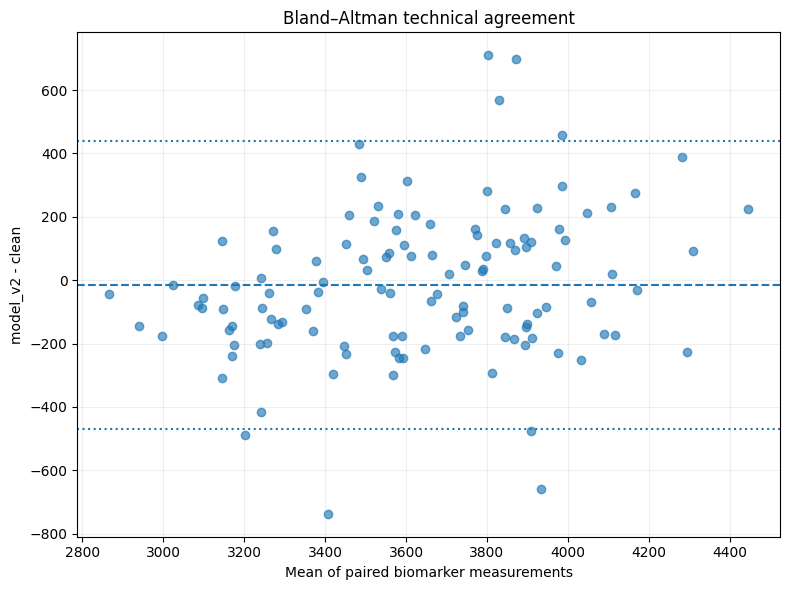

In [12]:

# Publication-style example Bland–Altman figure:
condition_a = "clean"
condition_b = "model_v2"

matched = matched_condition(
    evidence,
    condition_a,
    condition_b,
    visit="BL"
)

if len(matched) >= 3:
    r = bland_altman(matched["a"], matched["b"])

    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(r["mean_pair"], r["difference"], alpha=0.65)
    ax.axhline(r["bias"], linestyle="--")
    ax.axhline(r["loa_low"], linestyle=":")
    ax.axhline(r["loa_high"], linestyle=":")
    ax.set_xlabel("Mean of paired biomarker measurements")
    ax.set_ylabel(f"{condition_b} - {condition_a}")
    ax.set_title("Bland–Altman technical agreement")
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR/"bland_altman_clean_vs_model_v2.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()



# 8. Visit-level technical variability

This quantifies how much a patient-level biomarker moves when the visit/anatomy is held approximately constant but the technical condition changes.


In [13]:

# ============================================================
# 8. VISIT-LEVEL TECHNICAL VARIABILITY
# ============================================================

technical_conditions = evidence[
    ~evidence["perturbation"].eq("real_test_retest_demo")
].copy()

visit_stability = (
    technical_conditions
    .groupby(["subject_id","visit_id","split"], as_index=False)
    .agg(
        technical_mean=("biomarker_value","mean"),
        technical_sd=("biomarker_value","std"),
        technical_min=("biomarker_value","min"),
        technical_max=("biomarker_value","max"),
        reference_value=("reference_value","first"),
        mean_relative_error=("relative_error_from_reference","mean"),
        max_relative_error=("relative_error_from_reference","max"),
        n_conditions=("biomarker_value","size")
    )
)

visit_stability["technical_cv"] = (
    visit_stability["technical_sd"] /
    visit_stability["technical_mean"].abs()
)

visit_stability["relative_range"] = (
    (visit_stability["technical_max"] - visit_stability["technical_min"]) /
    visit_stability["reference_value"].abs()
)

display(visit_stability.head())


,subject_id,visit_id,split,technical_mean,technical_sd,technical_min,technical_max,reference_value,mean_relative_error,max_relative_error,n_conditions,technical_cv,relative_range
0,S001,BL,heldout,3790.512716,18.872912,3768.183972,3811.683068,3774.076403,0.004875,0.009964,6,0.004979,0.011526
1,S001,M12,heldout,3677.760156,60.636907,3572.849553,3740.577394,3707.508996,0.012351,0.036321,6,0.016487,0.045240
2,S002,BL,development,3592.425638,30.428972,3568.028259,3649.867264,3574.997987,0.005786,0.020942,6,0.008470,0.022892
3,S002,M12,development,3567.611835,72.733352,3467.018273,3644.911794,3467.018273,0.029014,0.051310,6,0.020387,0.051310
4,S003,BL,development,3761.222218,70.551391,3680.364182,3847.328685,3760.480612,0.014238,0.023095,6,0.018758,0.044400



# 9. Real/test-retest reliability

When a biological change should be minimal, the observed difference can serve as an independent technical-instability signal.

For the final paper, this should preferably use a true public test-retest cohort or a tightly spaced repeated MRI subset.


In [14]:

# ============================================================
# 9. TEST-RETEST
# ============================================================

test_retest = evidence[
    evidence["is_test_retest"].astype(bool)
].copy()

test_retest_summary = []

if len(test_retest):
    # If multiple test-retest rows exist, summarize within subject.
    tr_subject = (
        test_retest.groupby("subject_id", as_index=False)
        .agg(
            tr_mean=("biomarker_value","mean"),
            tr_sd=("biomarker_value","std"),
            tr_min=("biomarker_value","min"),
            tr_max=("biomarker_value","max"),
            tr_n=("biomarker_value","size")
        )
    )

    tr_subject["tr_cv"] = tr_subject["tr_sd"] / tr_subject["tr_mean"].abs()
    tr_subject["tr_relative_range"] = (
        (tr_subject["tr_max"] - tr_subject["tr_min"]) /
        tr_subject["tr_mean"].abs()
    )

    display(tr_subject.head())
else:
    tr_subject = pd.DataFrame()
    print("No test-retest rows found.")


,subject_id,tr_mean,tr_sd,tr_min,tr_max,tr_n,tr_cv,tr_relative_range
0,S001,3770.628310,51.249571,3722.572301,3839.023318,4,0.013592,0.030884
1,S002,3577.423490,32.897824,3529.915630,3604.575059,4,0.009196,0.020870
2,S003,3734.635029,27.208661,3695.736965,3753.649307,4,0.007285,0.015507
3,S004,3925.522860,53.350728,3860.777429,3983.003172,4,0.013591,0.031136
4,S005,3280.790734,58.322685,3205.615746,3345.512203,4,0.017777,0.042641



# 10. Longitudinal biological-vs-technical change

For each subject:

- biological longitudinal change = clean M12 − clean BL;
- technical envelope = variability across technical conditions within BL/M12;
- technical-to-biological ratio = technical variability divided by absolute longitudinal change.

A high ratio means the technical variability is large relative to the observed longitudinal change.


In [15]:

# ============================================================
# 10. BIOLOGICAL VS TECHNICAL CHANGE
# ============================================================

clean = evidence[evidence["perturbation"]=="clean"].copy()

bl = clean[clean.visit_id=="BL"][
    ["subject_id","biomarker_value","split"]
].rename(columns={"biomarker_value":"clean_bl"})

fu = clean[clean.visit_id=="M12"][
    ["subject_id","biomarker_value"]
].rename(columns={"biomarker_value":"clean_m12"})

long_change = bl.merge(fu, on="subject_id", how="inner")
long_change["longitudinal_change"] = (
    long_change["clean_m12"] - long_change["clean_bl"]
)
long_change["abs_longitudinal_change"] = (
    long_change["longitudinal_change"].abs()
)

tech_subject = (
    visit_stability[
        visit_stability["visit_id"].isin(["BL","M12"])
    ]
    .groupby("subject_id", as_index=False)
    .agg(
        mean_technical_sd=("technical_sd","mean"),
        max_technical_relative_range=("relative_range","max"),
        mean_technical_cv=("technical_cv","mean")
    )
)

long_change = long_change.merge(
    tech_subject,
    on="subject_id",
    how="left"
)

long_change["technical_to_longitudinal_ratio"] = (
    long_change["mean_technical_sd"] /
    long_change["abs_longitudinal_change"].replace(0,np.nan)
)

display(long_change.head())


,subject_id,clean_bl,split,clean_m12,longitudinal_change,abs_longitudinal_change,mean_technical_sd,max_technical_relative_range,mean_technical_cv,technical_to_longitudinal_ratio
0,S001,3774.076403,heldout,3707.508996,-66.567407,66.567407,39.754910,0.045240,0.010733,0.597213
1,S002,3574.997987,development,3467.018273,-107.979714,107.979714,51.581162,0.051310,0.014429,0.477693
2,S003,3760.480612,development,3703.685913,-56.794698,56.794698,60.170959,0.044400,0.016068,1.059447
3,S004,3929.349850,development,3921.377390,-7.972460,7.972460,166.367578,0.152319,0.042552,20.867785
4,S005,3298.400306,heldout,3202.401386,-95.998920,95.998920,109.569657,0.107808,0.034426,1.141363



# 11. Direction-of-change concordance

This is one of the paper's strongest patient-level endpoints.

For each technical condition, compare baseline → follow-up direction against the clean longitudinal direction.

A technical condition that flips `DECREASE` to `INCREASE`, or vice versa, is a clinically interpretable reliability failure mode even when absolute biomarker error looks modest.


In [16]:

# ============================================================
# 11. CHANGE DIRECTION CONCORDANCE
# ============================================================

def classify_change(delta, baseline, pct_threshold=0.02):
    threshold = abs(baseline)*pct_threshold
    if delta > threshold:
        return "INCREASE"
    if delta < -threshold:
        return "DECREASE"
    return "STABLE"

long_rows = []

conditions = sorted(
    set(evidence["perturbation"]) -
    {"real_test_retest_demo"}
)

for sid, g in evidence.groupby("subject_id"):
    for condition in conditions:
        b = g[
            (g.visit_id=="BL") &
            (g.perturbation==condition)
        ]
        f = g[
            (g.visit_id=="M12") &
            (g.perturbation==condition)
        ]

        if len(b)==0 or len(f)==0:
            continue

        bval = float(b.iloc[0].biomarker_value)
        fval = float(f.iloc[0].biomarker_value)

        long_rows.append({
            "subject_id": sid,
            "condition": condition,
            "baseline_value": bval,
            "followup_value": fval,
            "delta": fval-bval,
            "direction": classify_change(fval-bval,bval)
        })

longitudinal = pd.DataFrame(long_rows)

clean_direction = (
    longitudinal[
        longitudinal.condition=="clean"
    ][["subject_id","direction"]]
    .rename(columns={"direction":"clean_direction"})
)

longitudinal = longitudinal.merge(
    clean_direction,
    on="subject_id",
    how="left"
)

longitudinal["direction_preserved"] = (
    longitudinal["direction"] ==
    longitudinal["clean_direction"]
).astype(int)

direction_by_condition = (
    longitudinal
    .groupby("condition", as_index=False)
    .agg(
        direction_concordance=("direction_preserved","mean"),
        n=("subject_id","nunique")
    )
    .sort_values("direction_concordance")
)

display(direction_by_condition)


,condition,direction_concordance,n
5,resample_alt,0.325000,120
2,noise_high,0.358333,120
1,model_v2,0.366667,120
3,noise_low,0.541667,120
4,repeat_same_pipeline,0.616667,120
0,clean,1.000000,120


In [17]:

direction_subject = (
    longitudinal[
        longitudinal.condition!="clean"
    ]
    .groupby("subject_id", as_index=False)
    .agg(
        direction_stability=("direction_preserved","mean"),
        n_conditions=("condition","nunique")
    )
)

display(direction_subject.head())


,subject_id,direction_stability,n_conditions
0,S001,0.4,5
1,S002,0.0,5
2,S003,0.8,5
3,S004,0.6,5
4,S005,0.6,5



# 12. Site and scanner effects

A major ICHI question is whether site/scanner context explains meaningful variance in the biomarker even after subject identity is considered.

This section provides:

1. descriptive site/scanner summaries;
2. a mixed-effects model with subject random intercept;
3. an approximate variance decomposition.

For the final paper, expand this if a sufficiently large real multisite cohort is available.


In [18]:

# ============================================================
# 12. SITE / SCANNER DESCRIPTIVES
# ============================================================

site_summary = (
    clean.groupby("site", as_index=False)
    .agg(
        n_subjects=("subject_id","nunique"),
        mean_biomarker=("biomarker_value","mean"),
        sd_biomarker=("biomarker_value","std")
    )
)

scanner_summary = (
    clean.groupby("scanner", as_index=False)
    .agg(
        n_subjects=("subject_id","nunique"),
        mean_biomarker=("biomarker_value","mean"),
        sd_biomarker=("biomarker_value","std")
    )
)

display(site_summary)
display(scanner_summary)


,site,n_subjects,mean_biomarker,sd_biomarker
0,SITE_A,68,3593.896094,327.996508
1,SITE_B,28,3709.913734,333.373846
2,SITE_C,24,3495.160547,327.887880


,scanner,n_subjects,mean_biomarker,sd_biomarker
0,3T_A,41,3610.318953,311.039261
1,3T_B,38,3565.697446,338.841842
2,3T_C,41,3625.043708,356.618301


In [19]:

# Mixed-effects model:
# biomarker ~ visit + site + scanner + model_version + preprocessing_version
# random intercept by subject

model_df = evidence[
    evidence["visit_id"].isin(["BL","M12"])
].copy()

for c in [
    "visit_id",
    "site",
    "scanner",
    "model_version",
    "preprocessing_version",
    "perturbation"
]:
    model_df[c] = model_df[c].astype("category")

try:
    mixed = smf.mixedlm(
        "biomarker_value ~ C(visit_id) + C(site) + C(scanner) + C(model_version) + C(preprocessing_version) + C(perturbation)",
        model_df,
        groups=model_df["subject_id"]
    ).fit(reml=True, method="lbfgs")

    print(mixed.summary())

    subject_variance = float(mixed.cov_re.iloc[0,0])
    residual_variance = float(mixed.scale)
    total_random_variance = subject_variance + residual_variance

    variance_summary = pd.DataFrame([{
        "subject_random_intercept_variance": subject_variance,
        "residual_variance": residual_variance,
        "subject_fraction_of_random_variance":
            subject_variance/total_random_variance if total_random_variance else np.nan,
        "residual_fraction_of_random_variance":
            residual_variance/total_random_variance if total_random_variance else np.nan
    }])

    display(variance_summary)

except Exception as e:
    mixed = None
    variance_summary = pd.DataFrame()
    print("Mixed model could not be fit:", e)


Mixed model could not be fit: Singular matrix



# 13. Independent technical-instability reference

This is the key methodological correction relative to Notebook 19A.

The **final TRACE gate must not be evaluated against a label defined by TRACE's own score**.

For controlled perturbation/test-retest experiments, define instability using independent evidence such as:

- replicate disagreement exceeding a predeclared biological/technical tolerance;
- test-retest difference exceeding the empirical 95% repeatability interval;
- known severe perturbation condition that creates unacceptable measurement error;
- longitudinal direction flip relative to a clean/reference trajectory.

Below, the reference is constructed from **observed replicate disagreement and known technical deviation**, not from the later TRACE score.


In [20]:

# ============================================================
# 13. DEVELOPMENT-DERIVED INDEPENDENT REFERENCE THRESHOLDS
# ============================================================

# Development data only.
dev = evidence[evidence.split=="development"].copy()

# Use low-risk repeat-like conditions to characterize expected technical noise.
repeat_like = dev[
    dev["perturbation"].isin(["repeat_same_pipeline"])
].copy()

if len(repeat_like) >= 10:
    repeat_error_threshold = float(
        repeat_like["relative_error_from_reference"].quantile(0.95)
    )
else:
    # Fallback engineering default; replace/freeze with actual development estimate.
    repeat_error_threshold = 0.05

# Use development direction concordance to characterize severe flips.
dev_long = longitudinal[
    longitudinal.subject_id.isin(dev_subjects)
].copy()

reference_thresholds = {
    "repeat_relative_error_95th": repeat_error_threshold,
    "direction_flip_is_unstable": True,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "derived_from": "development_subjects_only"
}

with open(
    OUT_DIR/"independent_reference_thresholds.json",
    "w"
) as f:
    json.dump(reference_thresholds,f,indent=2)

print(json.dumps(reference_thresholds,indent=2))


{
  "repeat_relative_error_95th": 0.03771793081366974,
  "direction_flip_is_unstable": true,
  "created_utc": "2026-09-11T21:06:12.385865+00:00",
  "derived_from": "development_subjects_only"
}


In [21]:

# ============================================================
# 14. ASSIGN CONDITION-LEVEL INDEPENDENT INSTABILITY LABEL
# ============================================================

condition_eval = evidence[
    evidence["perturbation"]!="clean"
].copy()

condition_eval["independent_unstable_by_error"] = (
    condition_eval["relative_error_from_reference"] >
    repeat_error_threshold
).astype(int)

# Add subject/condition direction flip.
dir_lookup = longitudinal[
    longitudinal.condition!="clean"
][
    ["subject_id","condition","direction_preserved"]
].rename(columns={
    "condition":"perturbation",
    "direction_preserved":"direction_preserved_reference"
})

condition_eval = condition_eval.merge(
    dir_lookup,
    on=["subject_id","perturbation"],
    how="left"
)

condition_eval["independent_unstable_by_direction"] = (
    condition_eval["direction_preserved_reference"]==0
).astype(int)

condition_eval["independent_unstable"] = (
    (condition_eval["independent_unstable_by_error"]==1) |
    (condition_eval["independent_unstable_by_direction"]==1)
).astype(int)

display(
    condition_eval[
        [
            "subject_id",
            "visit_id",
            "perturbation",
            "relative_error_from_reference",
            "direction_preserved_reference",
            "independent_unstable"
        ]
    ].head(20)
)


,subject_id,visit_id,perturbation,relative_error_from_reference,direction_preserved_reference,independent_unstable
0,S001,BL,repeat_same_pipeline,0.001297,1.0,0
1,S001,BL,noise_low,0.001561,0.0,1
2,S001,BL,noise_high,0.008689,1.0,0
3,S001,BL,resample_alt,0.009964,0.0,1
4,S001,BL,model_v2,0.007741,0.0,1
5,S001,M12,repeat_same_pipeline,0.004063,1.0,0
6,S001,M12,noise_low,0.036321,0.0,1
7,S001,M12,noise_high,0.008919,1.0,0
8,S001,M12,resample_alt,0.013056,0.0,1
9,S001,M12,model_v2,0.011749,0.0,1


In [22]:

held_condition_eval = condition_eval[
    condition_eval.split=="heldout"
].copy()

reference_prevalence = (
    held_condition_eval["independent_unstable"].mean()
)

reference_summary = pd.DataFrame([{
    "heldout_subjects": held_condition_eval.subject_id.nunique(),
    "heldout_condition_rows": len(held_condition_eval),
    "independent_unstable_prevalence": reference_prevalence,
    "repeat_relative_error_threshold": repeat_error_threshold
}])

display(reference_summary)


,heldout_subjects,heldout_condition_rows,independent_unstable_prevalence,repeat_relative_error_threshold
0,36,432,0.543981,0.037718



# 16. Biological-vs-technical ambiguity figure

The figure compares:

- absolute clean longitudinal change;
- technical standard deviation.

Patients above the diagonal have technical variation larger than their observed clean longitudinal change.


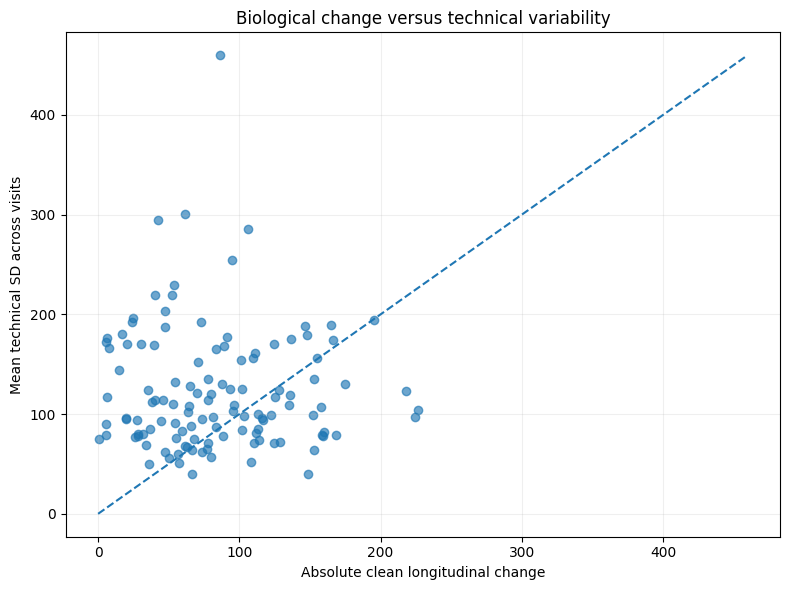

In [23]:

# ============================================================
# 16. BIOLOGICAL VS TECHNICAL FIGURE
# ============================================================

plot_df = long_change.dropna(
    subset=[
        "abs_longitudinal_change",
        "mean_technical_sd"
    ]
).copy()

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(
    plot_df["abs_longitudinal_change"],
    plot_df["mean_technical_sd"],
    alpha=0.65
)

limit = max(
    plot_df["abs_longitudinal_change"].max(),
    plot_df["mean_technical_sd"].max()
)

ax.plot([0,limit],[0,limit],linestyle="--")

ax.set_xlabel("Absolute clean longitudinal change")
ax.set_ylabel("Mean technical SD across visits")
ax.set_title("Biological change versus technical variability")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    FIG_DIR/"biological_vs_technical_change.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



# 17. Direction-concordance figure


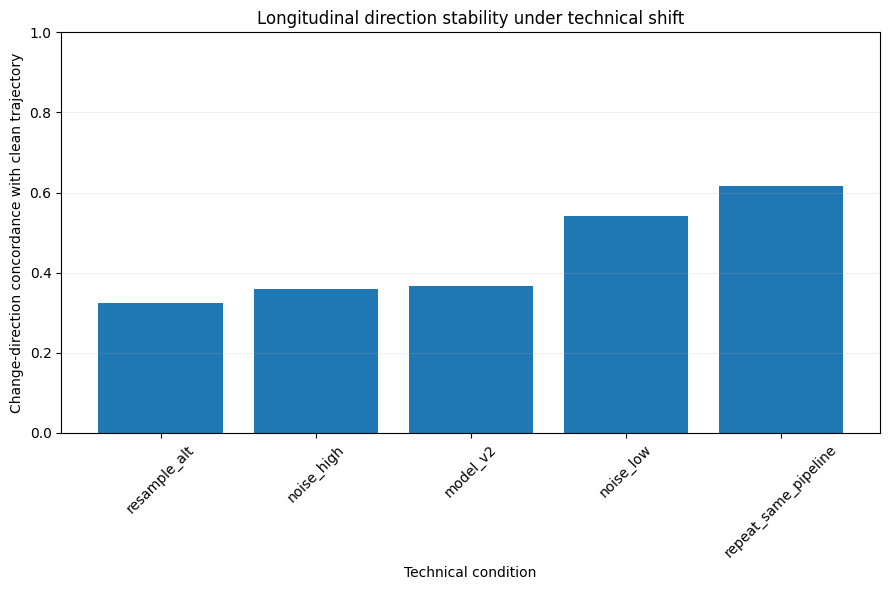

In [24]:

fig, ax = plt.subplots(figsize=(9,6))

d = direction_by_condition[
    direction_by_condition.condition!="clean"
].copy()

ax.bar(
    d["condition"],
    d["direction_concordance"]
)

ax.set_ylim(0,1)
ax.set_ylabel("Change-direction concordance with clean trajectory")
ax.set_xlabel("Technical condition")
ax.set_title("Longitudinal direction stability under technical shift")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(
    FIG_DIR/"direction_concordance_by_condition.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



# 18. Save analysis artifacts for Notebook 20

Notebook 20 should **not recreate** the subject split or the independent instability definition.

It should load the frozen artifacts produced here.


In [25]:

# ============================================================
# 18. EXPORT
# ============================================================

evidence.to_parquet(
    OUT_DIR/"evidence_19B_normalized.parquet",
    index=False
)

visit_stability.to_csv(
    OUT_DIR/"visit_level_technical_stability.csv",
    index=False
)

long_change.to_csv(
    OUT_DIR/"biological_vs_technical_change.csv",
    index=False
)

longitudinal.to_csv(
    OUT_DIR/"longitudinal_direction_concordance.csv",
    index=False
)

condition_eval.to_parquet(
    OUT_DIR/"independent_instability_reference.parquet",
    index=False
)

icc_df.to_csv(
    OUT_DIR/"icc_results.csv",
    index=False
)

ba_table.to_csv(
    OUT_DIR/"bland_altman_summary.csv",
    index=False
)

site_summary.to_csv(
    OUT_DIR/"site_summary.csv",
    index=False
)

scanner_summary.to_csv(
    OUT_DIR/"scanner_summary.csv",
    index=False
)

print("Saved all 19B artifacts to:", OUT_DIR)


Saved all 19B artifacts to: /content/neurofhir_trace/outputs_19B



# 19. Summary table


In [26]:

# ============================================================
# 19. SUMMARY
# ============================================================

summary = {
    "N_subjects": int(evidence.subject_id.nunique()),
    "N_development_subjects": int(len(dev_subjects)),
    "N_heldout_subjects": int(len(held_subjects)),
    "N_evidence_rows": int(len(evidence)),
    "median_visit_technical_CV": float(
        visit_stability.technical_cv.median()
    ),
    "median_direction_stability": float(
        direction_subject.direction_stability.median()
    ) if len(direction_subject) else np.nan,
    "heldout_independent_instability_prevalence": float(
        reference_prevalence
    ),
    "development_repeat_error_95th": float(
        repeat_error_threshold
    )
}

# Add best available ICC.
if len(icc_df):
    summary["median_ICC_2_1"] = float(
        icc_df["ICC_2_1"].median()
    )

# Add technical/biological ratio.
if len(long_change):
    summary["median_technical_to_longitudinal_ratio"] = float(
        long_change["technical_to_longitudinal_ratio"]
        .replace([np.inf,-np.inf],np.nan)
        .median()
    )

summary_df = pd.DataFrame([summary])
summary_df.to_csv(
    OUT_DIR/"ichi_trace_19B_summary.csv",
    index=False
)

display(summary_df.T)


,0
N_subjects,120.000000
N_development_subjects,84.000000
N_heldout_subjects,36.000000
N_evidence_rows,1680.000000
median_visit_technical_CV,0.029318
median_direction_stability,0.400000
heldout_independent_instability_prevalence,0.543981
development_repeat_error_95th,0.037718
median_ICC_2_1,0.843702
median_technical_to_longitudinal_ratio,1.371821



# 20. Interpretation checklist before Notebook 20

Do **not** optimize TRACE thresholds yet until the following are checked.

### A. Real longitudinal evidence
The final run should include a real longitudinal cohort with true subject-level visit linkage.

### B. Independent repeatability/generalization evidence
Strongest options, in order:

1. independent external cohort/site;
2. independent test-retest MRI dataset;
3. held-out site;
4. controlled perturbations on held-out subjects.

### C. Avoid circularity
The instability reference must be defined independently from the TRACE score.

### D. Freeze before held-out evaluation
Once development thresholds are selected:

- save them;
- do not retune on held-out subjects;
- evaluate held-out performance exactly once for the main result.

### E. Do not claim clinical ground truth
Technical stability and biological plausibility are not equivalent to diagnostic validity.

---

# Next Notebook — 20

## TRACE Gate Calibration + Frozen Held-Out Evaluation + Ablations

Notebook 20 should:

1. load `trace_subject_split.csv`;
2. load `independent_reference_thresholds.json`;
3. load `independent_instability_reference.parquet`;
4. compute candidate TRACE signals on **development subjects only**;
5. calibrate the TRUSTED / CAUTION / REVIEW_REQUIRED operating points;
6. freeze the gate;
7. evaluate once on held-out subjects;
8. compare:
   - uncertainty / variability only;
   - domain/site signal only;
   - provenance only;
   - longitudinal plausibility only;
   - full TRACE;
9. report:
   - AUROC;
   - AUPRC;
   - sensitivity/specificity;
   - review rate;
   - calibration;
   - false-change capture;
   - bootstrap confidence intervals.

That is the notebook where the 19A circular AUROC is replaced by a defensible held-out result.
